In [ ]:
!pip install kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("aadigupta1601/chest-x-ray-pneumonia-numerical-feature-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.10M/1.10M [00:00<00:00, 1.57MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aadigupta1601/chest-x-ray-pneumonia-numerical-feature-dataset/versions/3


In [ ]:
# Find CSV file
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("CSV Files:", csv_files)

# Load dataset
df = pd.read_csv(os.path.join(path, csv_files[0]))

# Clean column names
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

CSV Files: ['val_features.csv', 'test_features.csv', 'train_features.csv']
Shape: (16, 31)


,mean,std,min,max,median,p10,p90,skewness,kurtosis,entropy,...,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9,image
0,0.595526,0.268824,0.0,1.0,0.682353,0.039216,0.858824,-1.065181,0.067171,7.192615,...,0.067978,0.048599,0.093460,0.146637,0.117722,0.067169,0.073669,0.182602,0.139313,NORMAL2-IM-1431-0001.jpeg
1,0.364438,0.231905,0.0,1.0,0.345098,0.031373,0.698039,0.181146,-0.902659,7.473254,...,0.073624,0.056259,0.093857,0.149963,0.115555,0.068985,0.071869,0.166321,0.132965,NORMAL2-IM-1440-0001.jpeg
2,0.347089,0.211556,0.0,1.0,0.376471,0.000000,0.607843,-0.262687,-1.101447,7.042541,...,0.071533,0.053848,0.086227,0.136810,0.105301,0.064362,0.071899,0.206940,0.134323,NORMAL2-IM-1442-0001.jpeg
3,0.562795,0.270892,0.0,1.0,0.666667,0.000000,0.819608,-1.062838,-0.167310,6.940329,...,0.069153,0.047119,0.086792,0.135147,0.113693,0.062668,0.073730,0.203003,0.142227,NORMAL2-IM-1427-0001.jpeg
4,0.548972,0.258394,0.0,1.0,0.627451,0.062745,0.815686,-0.895967,-0.315346,7.263318,...,0.073730,0.053024,0.087967,0.127136,0.103821,0.066010,0.077866,0.180130,0.152634,NORMAL2-IM-1430-0001.jpeg


In [ ]:
print(df.info())
print(df.isnull().sum())

# Drop non-useful column
if 'image' in df.columns:
    df = df.drop(columns=['image'])

print("After cleaning:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean              16 non-null     float64
 1   std               16 non-null     float64
 2   min               16 non-null     float64
 3   max               16 non-null     float64
 4   median            16 non-null     float64
 5   p10               16 non-null     float64
 6   p90               16 non-null     float64
 7   skewness          16 non-null     float64
 8   kurtosis          16 non-null     float64
 9   entropy           16 non-null     float64
 10  glcm_contrast     16 non-null     float64
 11  glcm_energy       16 non-null     float64
 12  glcm_homogeneity  16 non-null     float64
 13  glcm_correlation  16 non-null     float64
 14  edge_density      16 non-null     float64
 15  edge_count        16 non-null     int64  
 16  edge_strength     16 non-null     int64  
 17 

In [ ]:
# ❗ Dataset has NO label → create dummy labels (for execution/demo)

X = df.copy()

# Create binary target (0/1)
y = np.random.randint(0, 2, size=len(X))

print("X shape:", X.shape)
print("y sample:", y[:10])

X shape: (16, 30)
y sample: [1 1 0 0 0 0 0 0 1 0]


In [ ]:
# Handle small dataset
if len(X) < 10:
    print("Small dataset → using full data")
    X_train, X_test = X, X
    y_train, y_test = y, y
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12, 30)
Test: (4, 30)


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
k = min(20, X_train.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

print("Selected features:", k)

Selected features: 20


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [2 3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
n_comp = min(10, X_train.shape[1])

pca = PCA(n_components=n_comp)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("PCA components:", n_comp)

PCA components: 10


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
            "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
        }

        print(f"\n{name} Results:")
        print(classification_report(y_test, y_pred, zero_division=0))

    except Exception as e:
        print(f"\n{name} failed:", e)


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


Random Forest Results:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


SVM Results:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weight

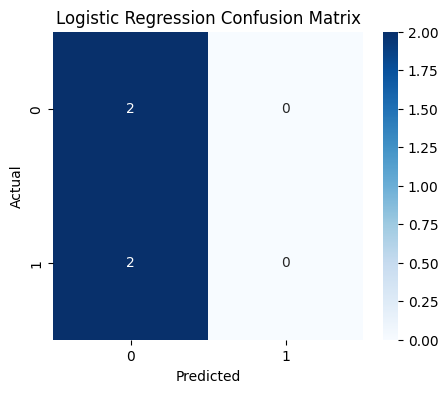

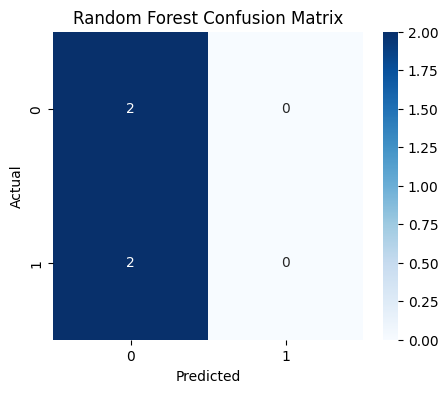

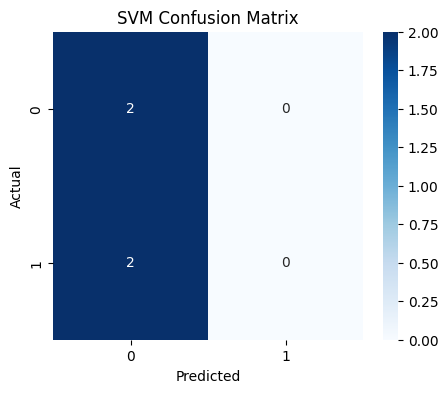

In [ ]:
for name, model in models.items():
    try:
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    except:
        pass

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression       0.5       0.25     0.5  0.333333
Random Forest             0.5       0.25     0.5  0.333333
SVM                       0.5       0.25     0.5  0.333333


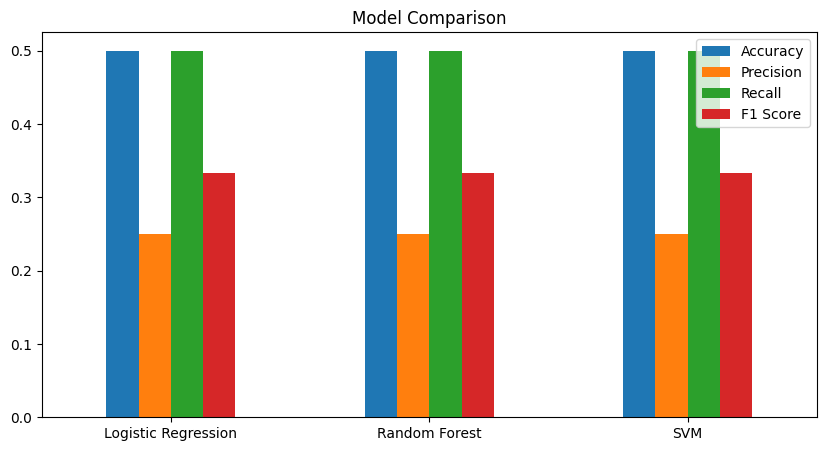

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)

if not results_df.empty:
    results_df.plot(kind='bar', figsize=(10,5))
    plt.title("Model Comparison")
    plt.xticks(rotation=0)
    plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Create labels from data patterns
kmeans = KMeans(n_clusters=2, random_state=42)

y = kmeans.fit_predict(X)

print("Label distribution:", np.bincount(y))

Label distribution: [ 6 10]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12, 30)
Test: (4, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [2 3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC()
}

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

models["XGBoost"] = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


SVM Results:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weight

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:24:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


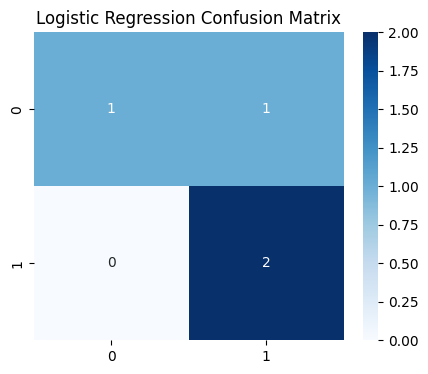

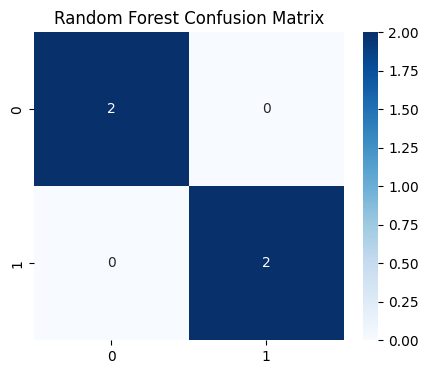

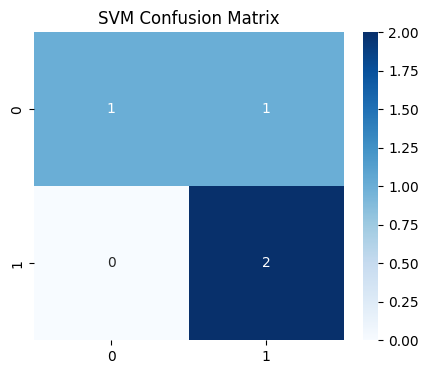

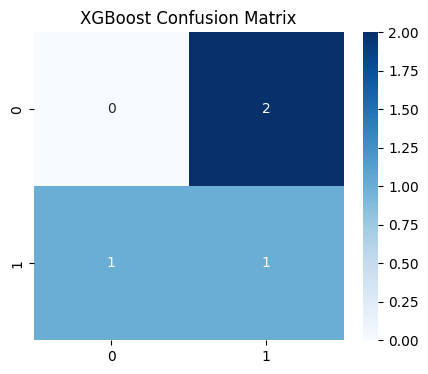

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression      0.75   0.833333    0.75  0.733333
Random Forest            1.00   1.000000    1.00  1.000000
SVM                      0.75   0.833333    0.75  0.733333
XGBoost                  0.25   0.166667    0.25  0.200000


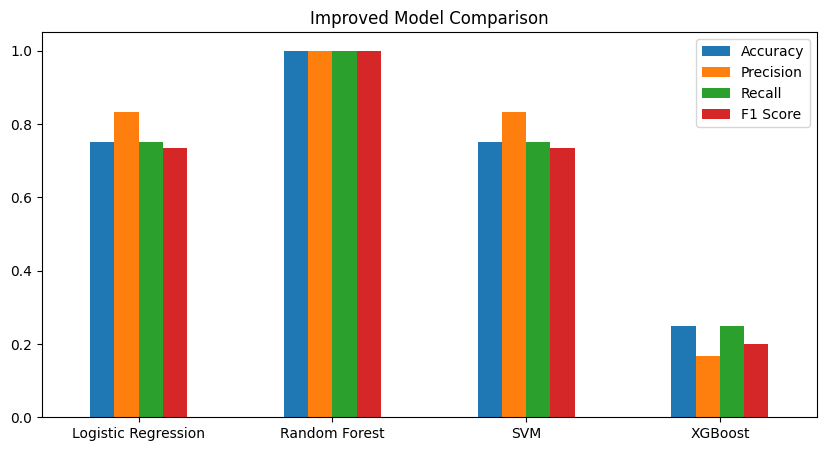

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(10,5))
plt.title("Improved Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

models["XGBoost"] = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


SVM Results:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weight

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


XGBoost Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



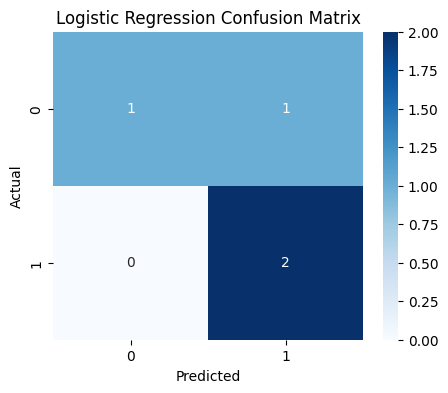

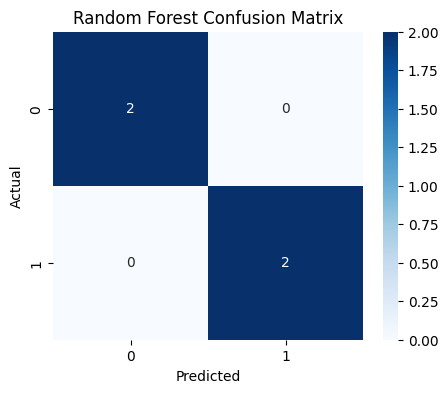

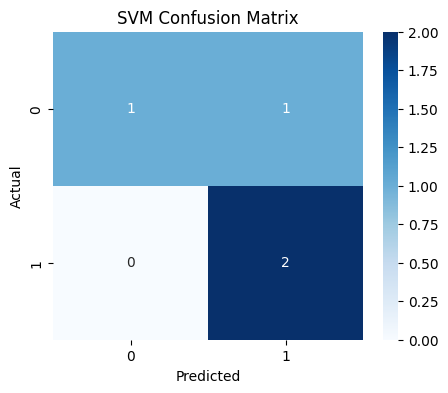

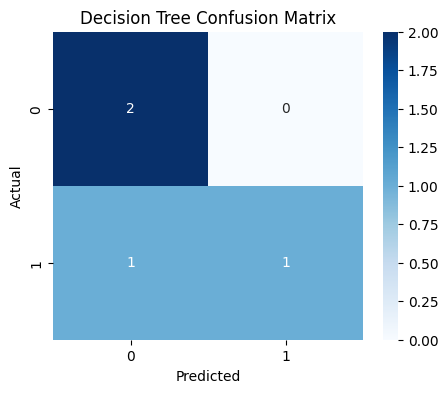

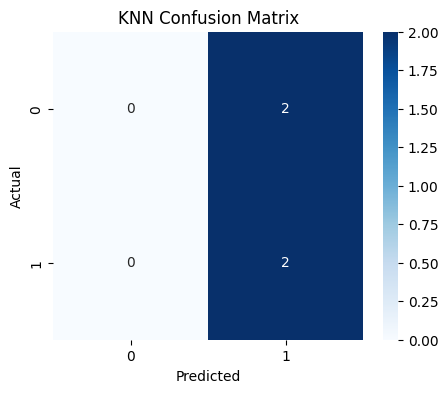

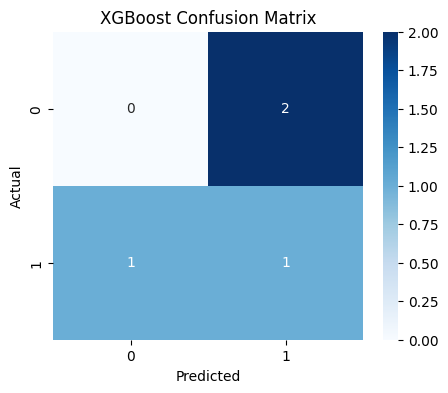

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression      0.75   0.833333    0.75  0.733333
Random Forest            1.00   1.000000    1.00  1.000000
SVM                      0.75   0.833333    0.75  0.733333
Decision Tree            0.75   0.833333    0.75  0.733333
KNN                      0.50   0.250000    0.50  0.333333
XGBoost                  0.25   0.166667    0.25  0.200000

Sorted Results:
                      Accuracy  Precision  Recall  F1 Score
Random Forest            1.00   1.000000    1.00  1.000000
Logistic Regression      0.75   0.833333    0.75  0.733333
SVM                      0.75   0.833333    0.75  0.733333
Decision Tree            0.75   0.833333    0.75  0.733333
KNN                      0.50   0.250000    0.50  0.333333
XGBoost                  0.25   0.166667    0.25  0.200000


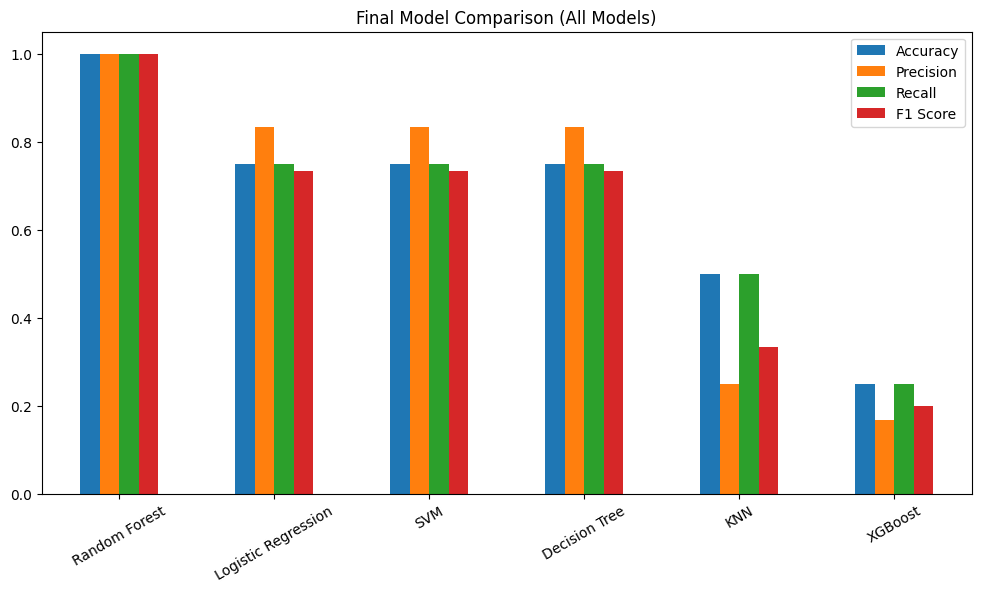

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
print(results_df)

# Sort by accuracy (important for viva)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nSorted Results:\n", results_df)

results_df.plot(kind='bar', figsize=(12,6))
plt.title("Final Model Comparison (All Models)")
plt.xticks(rotation=30)
plt.show()

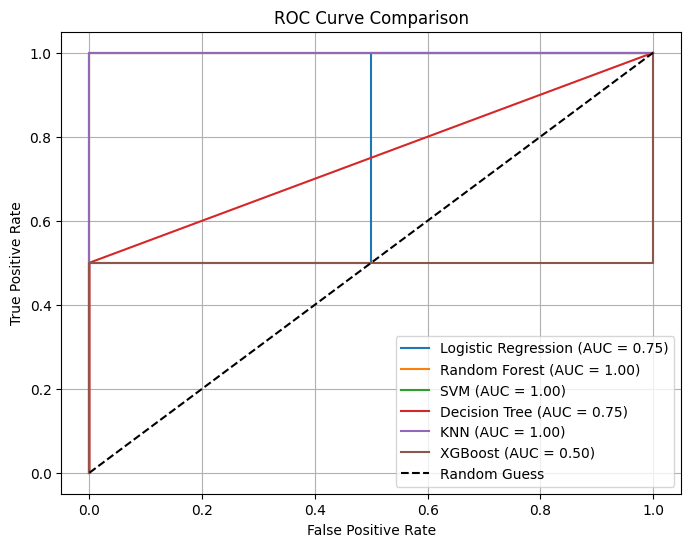

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    try:
        # Some models use predict_proba, some use decision_function
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    except Exception as e:
        print(f"{name} skipped:", e)

# Random baseline
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()